# Module 16: Naive Bayes Classifier
## Section – Implementing Naive Bayes on a Dataset

In this notebook we will **implement Naive Bayes step by step** on:

1. A **numeric dataset** (Breast Cancer Wisconsin) using `GaussianNB`.
2. A **text dataset** (small example + 20 Newsgroups subset) using `MultinomialNB`.

The goal is to make the process easy to follow:
- Load and understand the data
- Train Naive Bayes models
- Evaluate with accuracy, confusion matrix, and classification report
- Connect each step with the theory from the slides and whiteboard notes


In [1]:
# ===============================================================
# Imports and basic setup
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (7, 4)

---
## Part A – Gaussian Naive Bayes on a Numeric Dataset

We start with the **Breast Cancer Wisconsin** dataset from `sklearn.datasets`.
This is a binary classification problem:
- Class 0: malignant
- Class 1: benign

Features are **continuous numeric measurements** of cell nuclei, so `GaussianNB` is appropriate.


### 1. Load and Inspect the Dataset

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

print('Shape of X (features):', X.shape)
print('Shape of y (labels):', y.shape)
print('Target names:', data.target_names)
print('\nFirst 5 feature names:')
print(data.feature_names[:5])

Shape of X (features): (569, 30)
Shape of y (labels): (569,)
Target names: ['malignant' 'benign']

First 5 feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [4]:
# Put into a DataFrame for easier viewing
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2. Class Distribution

target
1    357
0    212
Name: count, dtype: int64


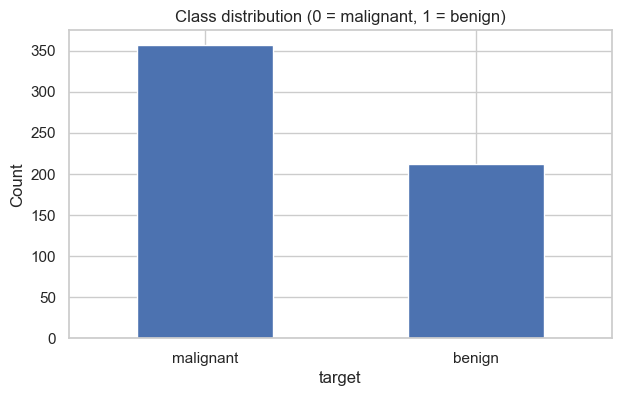

In [6]:
class_counts = df['target'].value_counts()
print(class_counts)

plt.figure()
class_counts.plot(kind='bar')
plt.xticks(ticks=[0,1], labels=data.target_names, rotation=0)
plt.title('Class distribution (0 = malignant, 1 = benign)')
plt.ylabel('Count')
plt.show()